<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/11_exgaussian_flat_priors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 11 — Flat population-level priors

Notebook 9 chose its priors so that each one said something plausible about reaction times. Notebook 10 replaced three of them with wide priors written directly on the log scale and never translated into milliseconds.

This notebook goes further and removes prior information altogether from the four population-level (or common-effect) parameters: the typical intercept and slope, the typical Gaussian standard deviation, and the tail mean shared by all participants. Their priors become flat, giving every value the same weight, while the priors for how much participants differ from one another stay Notebook 9's. Flat priors are often chosen in the hope of letting the data speak for themselves. Here they are chosen for you as a deliberate demonstration, not as a recommendation: the model is fitted to be diagnosed, not to be used. The purpose of this notebook is to see what a flat prior claims, which step of the workflow it removes, and whether the model can still be fitted.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

participants = sorted(sleep["Subject"].unique(), key=int)
participant_to_idx = {participant: i for i, participant in enumerate(participants)}
participant_idx = sleep["Subject"].map(participant_to_idx).to_numpy()

assert participant_idx.min() == 0
assert participant_idx.max() == len(participants) - 1
assert np.array_equal(
    np.asarray(participants)[participant_idx],
    sleep["Subject"].to_numpy(),
)

print(f"{len(participants)} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helper

The participant plotting helper from the previous notebooks is supplied. It can optionally restrict plots to selected participants using the standard ArviZ `coords` argument. Panels appear in participant order (308, 309, …, 372), left to right and top to bottom.

In [4]:
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}

PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(
        sleep[["Subject", "Days"]],
        names=["participant", "day"],
    ),
    "obs_id",
)

def plot_participants(dt, group, var, coords=None):
    """One panel per participant, optionally restricted with ArviZ coords."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="day",
        coords=coords,
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")
    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    return pc

## 1. Removing prior information

### 1.1 The model

The model is Notebook 9's:

$$
y_i \sim \operatorname{ExGaussian}(\mu_{y,i}, sd_{y,s[i]}, \nu)
$$

$$
\mu_{y,i}
=
b_{0,s[i]}
+
b_{1,s[i]}\,\mathrm{days}_i
$$

$$
b_{0,s}
\sim
\operatorname{Normal}(\mu_{b0}, sd_{b0})
$$

$$
b_{1,s}
\sim
\operatorname{Normal}(\mu_{b1}, sd_{b1})
$$

$$
\log sd_{y,s}
\sim
\operatorname{Normal}(\mu_{\log sd_y}, sd_{\log sd_y}).
$$

Here $s[i]$ identifies the participant who produced observation $i$, and the tail mean $\nu$ is shared by all participants. Only the priors of the four population-level parameters change:

| Parameter | Notebook 9 | This notebook |
|---|---|---|
| `mu_b0`, $\mu_{b0}$ | $\operatorname{Normal}(250, 100)$ | flat |
| `mu_b1`, $\mu_{b1}$ | $\operatorname{Normal}(0, 20)$ | flat |
| `mu_log_sd_y`, $\mu_{\log sd_y}$ | $\operatorname{Normal}(\log 30, 0.5)$ | flat |
| `log_nu`, $\log \nu$ | $\operatorname{Normal}(\log 50, 0.75)$ | flat |

The priors for the three between-participant standard deviations, `sd_b0`, `sd_b1`, and `sd_log_sd_y`, are Notebook 9's, and so are the construction of `sd_y` and `nu` and the likelihood.

### 1.2 What does a flat prior claim?

PyMC writes a flat prior as `pm.Flat`, whose density has the same value for every real number. What does `pm.Flat("mu_b0")` say about the typical baseline location of the Gaussian part, in milliseconds? Can a density that has the same value everywhere be a probability distribution?

That every value is equally plausible: a typical baseline location of 250 ms, of −1,000,000 ms, or of $10^{9}$ ms. Notebook 9's prior, $\operatorname{Normal}(250, 100)$, instead put about 95% of its probability between 50 and 450 ms.

It cannot be a probability distribution. The area under a probability density must be 1, but a density with the same value over the whole real line has infinite area, whatever that value is. Such a prior is called **improper**. It is often described as uninformative, but it still makes a claim: that no value, however absurd, is less plausible than any other.

### 1.3 What does a flat prior on $\log \nu$ say about the tail mean in milliseconds?

In Notebook 10 (Question 1.3), we translated a prior on $\log \nu$ into milliseconds. A flat prior on $\log \nu$ gives equal weight to intervals of equal width on the log scale. What does it say about tail means of 0.001–0.01 ms, 1–10 ms, and 10–100 ms? How much weight does it give to tails shorter than 1 ms, compared with Notebook 9's plausible range of 11–220 ms?

It gives the three ranges the same weight. Each spans a factor of ten, a width of $\log 10 \approx 2.3$ on the log scale, so a tail of 0.001–0.01 ms is exactly as plausible as one of 1–10 ms or 10–100 ms.

Below 1 ms there are infinitely many such factors of ten, down to $10^{-100}$ ms and beyond, each with the same weight. The prior therefore gives infinitely more weight to tails shorter than 1 ms, far too short to affect a reaction time, than to Notebook 9's 11–220 ms or to any other bounded range. The same holds in the other direction, for tails longer than any plausible reaction time.

### 1.4 The supplied model

The whole model is supplied in one cell. It is Notebook 9's code with `pm.Flat` for the four population-level parameters; Notebook 9's priors are shown in the comments. Notebook 9's `mean_rt` is left out, because no question here uses it.

In [5]:
coords = {
    "obs_id": np.arange(len(sleep)),
    "participant": participants,
}

# Hyperprior constants for the between-participant standard deviations, from Notebook 9
sd_sd_b0 = 25          # ms
sd_sd_b1 = 10          # ms/day
sd_sd_log_sd_y = 1 / 3

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    # Varying intercepts, with a flat population center
    mu_b0 = pm.Flat("mu_b0")  # Notebook 9: Normal(250, 100)
    sd_b0 = pm.Exponential("sd_b0", scale=sd_sd_b0)
    b0 = pm.Normal("b0", mu=mu_b0, sigma=sd_b0, dims="participant")

    # Varying slopes, with a flat population center
    mu_b1 = pm.Flat("mu_b1")  # Notebook 9: Normal(0, 20)
    sd_b1 = pm.Exponential("sd_b1", scale=sd_sd_b1)
    b1 = pm.Normal("b1", mu=mu_b1, sigma=sd_b1, dims="participant")

    # Location of the Gaussian part (ms)
    mu_y = pm.Deterministic(
        "mu_y",
        b0[pidx] + b1[pidx] * days,
        dims="obs_id",
    )

    # Participants' Gaussian standard deviations, with a log link and a flat population center
    mu_log_sd_y = pm.Flat("mu_log_sd_y")  # Notebook 9: Normal(log 30, 0.5)
    sd_log_sd_y = pm.Exponential("sd_log_sd_y", scale=sd_sd_log_sd_y)
    log_sd_y = pm.Normal(
        "log_sd_y",
        mu=mu_log_sd_y,
        sigma=sd_log_sd_y,
        dims="participant",
    )
    sd_y = pm.Deterministic("sd_y", pm.math.exp(log_sd_y), dims="participant")

    # Shared tail mean, with a log link and a flat prior
    log_nu = pm.Flat("log_nu")  # Notebook 9: Normal(log 50, 0.75)
    nu = pm.Deterministic("nu", pm.math.exp(log_nu))

    y = pm.ExGaussian(
        "y",
        mu=mu_y,
        sigma=sd_y[pidx],
        nu=nu,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

### 1.5 Why does this notebook have no prior predictive check?

In Notebook 10, the prior predictive check exposed the priors' problems before any fitting (Question 2.6 there). What does a prior predictive check need to draw first, and why can it not do so here?

It first draws parameter values from the prior, and then simulates reaction times from each draw. A flat prior has no distribution to draw from: there is no way to pick a real number at random with every value equally likely. PyMC refuses: for this model, `pm.sample_prior_predictive` stops with the error *Cannot sample from flat variable*.

With flat priors, the model therefore makes no claim about reaction times that can be checked before the data are used, and the step of the workflow that caught Notebook 10's priors before fitting does not exist. That absence is part of the lesson.

## 2. Fit and diagnose the model

### 2.1 Sample from the posterior.

The model is sampled with `target_accept=0.97` and 2,500 tuning draws. These settings are not the cause of what follows: in test runs, PyMC's default settings gave even more divergences, and Notebook 9's `target_accept=0.99` left three of the four chains stuck. Expect sampling to take several minutes. When a sampler fails, the details of the failure can differ from one computer to another, and with this model even the overall picture can differ in one respect, explained in Question 2.5.

In [6]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=2500,
        chains=4,
        target_accept=0.97,
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu_b0, sd_b0, b0, mu_b1, sd_b1, b1, mu_log_sd_y, sd_log_sd_y, log_sd_y, log_nu]


Output()

Sampling 4 chains for 2_500 tune and 1_000 draw iterations (10_000 + 4_000 draws total) took 292 seconds.


There were 1488 divergences after tuning. Increase `target_accept` or reparameterize.


Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


### 2.2 Check population-level diagnostics.

Besides the divergences, the code reports how often the sampler reached its maximum tree depth (Notebook 10, Question 3.3), and its average step size. The summary and trace show `log_nu` rather than `nu`, because its draws span many orders of magnitude.

In [7]:
sample_stats = idata["sample_stats"]
print("Divergences:", int(sample_stats["diverging"].sum().item()))
print(f"Draws at the maximum tree depth: {sample_stats['reached_max_treedepth'].mean().item():.1%}")
print(f"Average step size: {sample_stats['step_size'].mean().item():.4f}")

azs.summary(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "mu_log_sd_y", "sd_log_sd_y", "log_nu"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Divergences: 1488
Draws at the maximum tree depth: 25.2%
Average step size: 0.0059


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b0,262.23,12.08,241.20,280.15,8.78,17.22,1.38,4.34,1.36
sd_b0,33.17,7.12,21.71,44.25,19.47,18.75,1.14,1.44,0.25
mu_b1,10.72,2.45,6.66,14.54,15.07,19.59,1.20,0.66,0.25
sd_b1,7.93,1.71,5.12,10.46,25.55,86.94,1.13,0.33,0.07
mu_log_sd_y,0.88,3.39,-5.00,3.01,6.90,6.12,1.58,1.69,0.97
sd_log_sd_y,0.47,0.29,0.00,0.77,6.81,4.95,1.59,0.14,0.07
log_nu,-139.82,124.00,-320.11,3.73,7.19,11.37,1.53,41.78,3.43


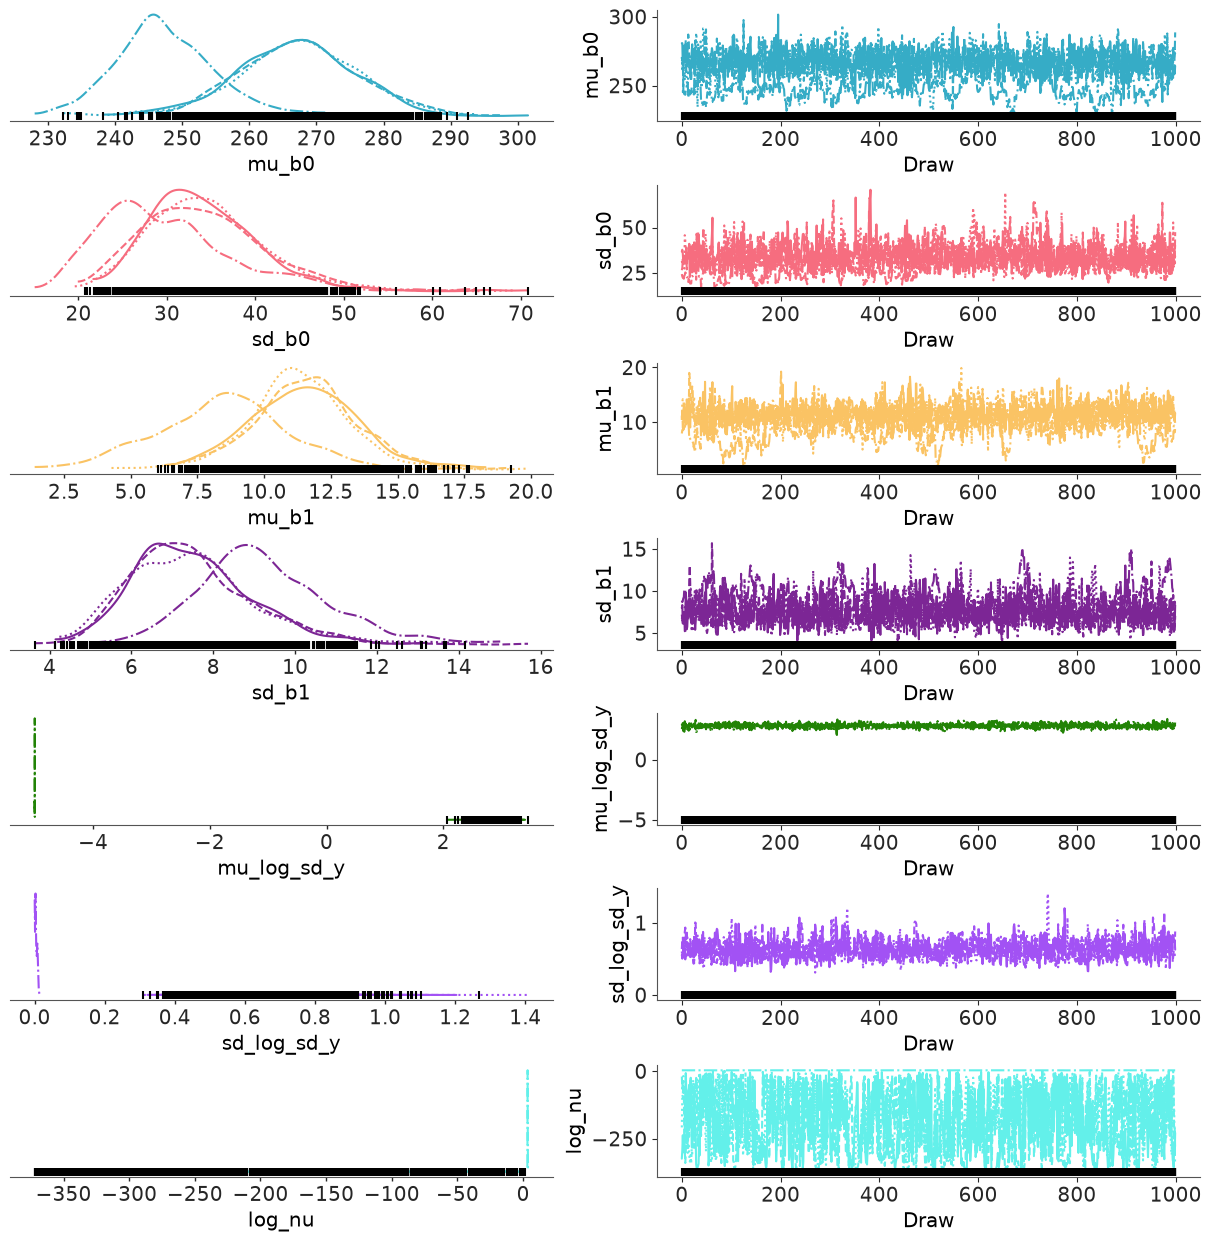

In [8]:
azp.plot_trace_dist(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "mu_log_sd_y", "sd_log_sd_y", "log_nu"],
);

### 2.3 Screen all participants.

In [9]:
participant_diagnostics = azs.summary(
    idata,
    var_names=["b0", "b1", "log_sd_y"],
    kind="diagnostics",
    round_to=2,
)

pd.DataFrame(
    {
        "value": [
            participant_diagnostics["r_hat"].max(),
            participant_diagnostics["ess_bulk"].min(),
            participant_diagnostics["ess_tail"].min(),
        ]
    },
    index=["largest R-hat", "smallest bulk ESS", "smallest tail ESS"],
)

,value
largest R-hat,1.60
smallest bulk ESS,6.80
smallest tail ESS,4.59


### 2.4 Does the fit meet the diagnostic criteria?

Use the criteria established in Notebook 1: no divergences, R-hat close to 1, adequate bulk and tail ESS, and well-mixed traces. Read the warnings printed by the sampling cell as well as the summaries, and compare the scale of `log_nu` with Notebook 9's 90% HDI for $\nu$, about 3.7–11 ms, or about 1.3–2.4 on the log scale.

No, on every criterion. 1,488 of the 4,000 draws ended in a divergence, and PyMC also warns that chain 3 reached the maximum tree depth, that R-hat exceeds 1.01, and that some effective sample sizes are very small. R-hat reaches about 1.6 for `mu_log_sd_y`, `sd_log_sd_y`, `log_nu`, and some participants' parameters, and the smallest ESS values are below 10.

In the traces, one chain sits apart from the other three: its densities for `mu_b0` and `mu_b1` lie lower than theirs, its `mu_log_sd_y` stays near −5 where theirs stays near 2.8, its `sd_log_sd_y` stays near 0, and its `log_nu` stays near 3, while the other three chains' `log_nu` sweeps back and forth between about −370 and 0. Even those three chains are nowhere near Notebook 9's 90% HDI of about 1.3–2.4 for `log_nu`.

### 2.5 Why can a chain sit far away from the others?

PyMC starts each chain with every flat parameter near zero: trajectories near 0 ms, Gaussian standard deviations of about 1 ms, and a tail mean of about 1 ms. From there, most chains move to trajectories like those of Notebook 9's fit. But a chain can instead settle where the Gaussian part has all but vanished: the Gaussian standard deviations shrink to thousandths of a millisecond or less, each participant's trajectory lies just below all of their observations, and a tail of tens to hundreds of milliseconds accounts for all of the scatter. Once the Gaussian part is that narrow, the data cannot tell it from no Gaussian part at all, and the flat prior on `mu_log_sd_y`, unlike Notebook 9's, does not rule out such tiny standard deviations. Every observation then acts as a wall (Notebook 9, Question 3.2), so the chain takes tiny steps, often reaches the maximum tree depth, and barely moves: it is stuck.

Whether a chain gets stuck depends on tiny numerical details, so it can differ from one computer to another, and even from one run to the next. In ten test runs of this notebook, about 40% of the chains got stuck, and nine of the ten runs had at least one stuck chain. In the one run in which no chain got stuck, the fit still had almost 2,000 divergences, but every population-level R-hat was 1.00. A stuck chain shows up as R-hat far above 1, as a trace that sits apart from the others, and in the chain means printed below.

In [10]:
idata["posterior"].to_dataset()[["mu_b0", "mu_b1", "mu_log_sd_y", "log_nu"]].mean("draw").to_dataframe().round(2)

,mu_b0,mu_b1,mu_log_sd_y,log_nu
chain,,,,
0,266.79,11.54,2.84,-190.09
1,267.50,11.60,2.84,-192.88
2,267.24,11.29,2.82,-179.74
3,247.39,8.44,-5.00,3.44


## 3. Read the failed fit

### 3.1 Where do the draws of `log_nu` lie?

A fit that fails its diagnostics is not reported, but its draws can still show what shaped them, and that helps explain the failure. Use the trace and density of `log_nu` in Question 2.2 and the chain means in Question 2.5. How are the draws of the chains that did not get stuck spread, and what tail means in milliseconds do the two ends of the spread correspond to?

The three chains that did not get stuck, 0, 1, and 2, spread their draws almost evenly between about −372 and about 0. In the trace, each of them sweeps back and forth across that whole range; under the density, their draws form a solid bar, and their density is too low to see next to the stuck chain's narrow peak. In milliseconds, the range runs from tails of about $e^{-372} \approx 10^{-162}$ ms up to about 1 ms.

Only the upper end reflects the data, which rule out long tails, as in Notebook 9's well-sampled fit. Below it lie tails far too short to affect any reaction time. The stuck chain, 3, stays near 3.4, a tail of about 30 ms (Question 2.5).

### 3.2 Why does nothing stop `log_nu` from decreasing?

In Notebook 10, the data bounded the tail only from above, and the $\operatorname{Normal}(0, 5)$ prior held the posterior back from ever shorter tails (Question 4.4 there). Once the tail is far shorter than every participant's Gaussian standard deviation, how does the likelihood change as $\log \nu$ decreases further? What does that imply for the posterior of $\log \nu$ under a flat prior?

It does not change. Once the tail is far shorter than every participant's Gaussian standard deviation, the ex-Gaussian is indistinguishable from a Gaussian (Notebook 9, Question 4.4), and PyMC computes it with exactly the Gaussian formula (Notebook 10, Question 4.5), whatever the value of $\nu$. The posterior is proportional to the prior times the likelihood, and a flat prior times a constant is constant: every value of $\log \nu$ below about −3, down to minus infinity, is equally supported.

A constant over an infinitely long range has infinite area, so, like the prior, this posterior is **improper**: it is not a probability distribution at all. The sampler has nothing to converge to, and nothing in the model stops `log_nu` from decreasing. A stuck chain has found the same problem in the other part of the likelihood: there, it is the Gaussian part that the data cannot tell from nothing (Question 2.5).

### 3.3 Then what stops the draws near −372, and where do the divergences come from?

The sampler's paths are steered by the slope of the log posterior density (Notebook 10, Question 3.3), and throughout the flat region that slope is exactly zero in the direction of `log_nu`, so nothing pulls the paths back. What stops them is the computer's arithmetic. A computer stores numbers in a limited range, and the smallest positive number it can store is about $5 \times 10^{-324}$. At $\log \nu \approx -372.5$, the tail mean is about $10^{-162}$ ms, and its square is too small to store: it becomes zero. Part of PyMC's slope calculation divides by that square, and once it is zero, the calculation produces *not a number* (NaN), a value that is no number at all. A path that reaches this point cannot continue, and the sampler reports a divergence. The lower edge of the draws is this limit of the arithmetic, not anything in the model or the data.

During tuning, the sampler learns how widely each parameter ranges and scales its steps for that parameter accordingly. For `log_nu`, the range is hundreds of units, so a single path can carry it a long way across the flat region, and many paths run into the limit. Here, divergences do not mark a part of the posterior that is too sharply curved for the sampler's steps (Notebook 9, Question 3.2); they mark the edge of what the computer can calculate. Increasing `target_accept`, as the warning suggests, makes the steps smaller, but no step size avoids that edge.

The failure differs from Notebook 10's. There, a proper prior kept $\log \nu$ within a range of about 20 units, where PyMC's switch to the Gaussian formula makes the density jump slightly; the sampler shrank its steps, almost every draw reached the maximum tree depth, and nothing diverged. Here, in the chains that reach the flat region, the steps are larger, almost no draw reaches the maximum tree depth, and about half of the draws diverge. The cause is the same: a prior that puts its weight where the data carry no information.

### 3.4 Summarize only the chains that reached the flat region.

Repeat the population-level summary of Question 2.2 for the chains that did not get stuck, selecting them with the `coords` argument, as for participants in Notebook 9 (Question 3.5). Use the chain means in Question 2.5 to decide which chains to keep.

In [11]:
azs.summary(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "mu_log_sd_y", "sd_log_sd_y", "log_nu"],
    coords={"chain": [0, 1, 2]},
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b0,267.18,8.90,252.35,281.24,1111.21,1026.48,1.0,0.27,0.26
sd_b0,34.26,6.56,23.80,44.37,1109.25,1031.99,1.0,0.20,0.18
mu_b1,11.48,1.94,8.27,14.55,1255.87,1194.14,1.0,0.05,0.05
sd_b1,7.49,1.52,5.16,9.86,1337.38,1321.94,1.0,0.04,0.04
mu_log_sd_y,2.83,0.17,2.57,3.11,1331.91,1345.26,1.0,0.00,0.00
sd_log_sd_y,0.63,0.13,0.43,0.82,1027.86,1341.84,1.0,0.00,0.00
log_nu,-187.57,106.68,-345.59,-14.46,549.65,571.22,1.0,4.41,1.40


### 3.5 What can R-hat and ESS detect here?

R-hat compares the chains with one another, and ESS estimates how many independent draws the chains are worth. Compare their values in your summary with those in Question 2.2. Does leaving out a stuck chain repair the fit?

Without chain 3, every R-hat is 1.00 and the smallest bulk and tail ESS, for `log_nu`, are about 550 and 570: by these numbers, the three chains agree and mix well. They do. Each wandered through the same region of `log_nu`, bounded above by the data near 0 and below by the limit of the arithmetic near −372, and each path carried `log_nu` a long way.

Leaving out the stuck chain repairs nothing. All 1,488 divergences came from these three chains, half of their draws. R-hat and ESS can check only that chains agree with one another and move freely; they cannot check that what the chains agree on is the model's posterior. Here, the lower edge comes from the computer, not from the model, and the posterior the chains appear to describe does not exist (Question 3.2). A run in which no chain gets stuck shows this same picture with all four chains (Question 2.5), and then only the divergences reveal the failure.

### 3.6 Generate and plot posterior predictive reaction times.

This fit's predictions will not be used, as in Notebook 10. The question here is different: had the diagnostics been skipped, would the posterior predictive check have raised an alarm? Generate replicated values of `y`, add them to `idata`, and plot them with `plot_participants`, as in Notebook 9 (Question 5.3).

Sampling: [y]


Output()

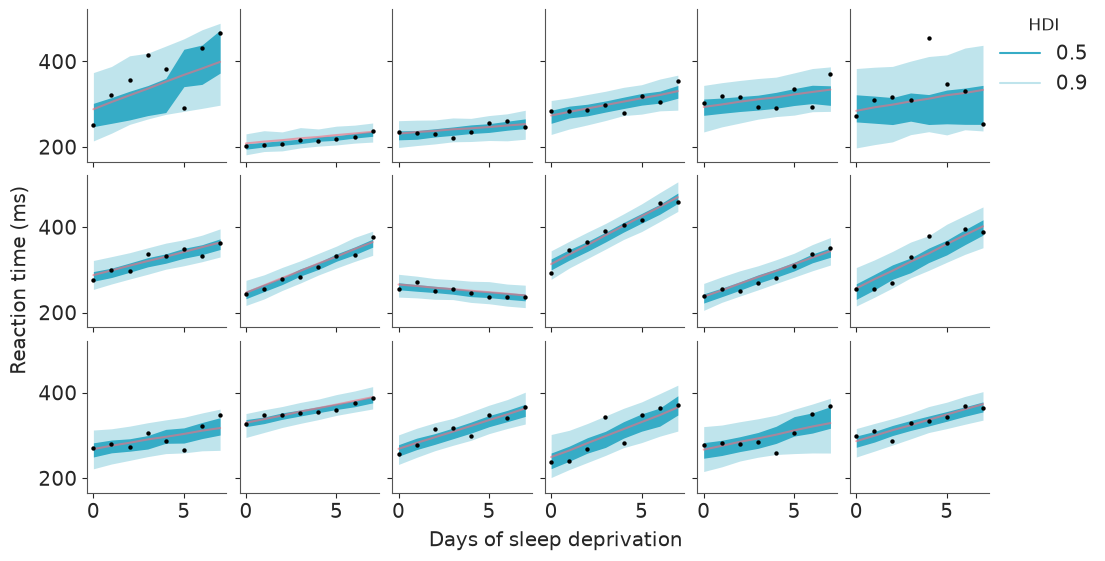

In [12]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

plot_participants(idata, "posterior_predictive", "y")
plt.show()

### 3.7 Would this check have revealed the problem?

Compare the plot with Notebook 9's (Question 5.3 there). Would the predicted reaction times differ if the tail mean were $10^{-5}$ ms rather than $10^{-150}$ ms?

No clear alarm. As in Notebook 9, each participant's bands follow their trajectory and their own day-to-day scatter, and almost every observation falls inside the 90% bands; the clearest exception is participant 332's slow reaction time on day 4, as in Notebook 9. The stuck chain's draws, whose trajectories lie below all of a participant's observations, pull a few 50% bands downward and make them lopsided, most visibly for participants 308 and 332. Nothing in the plot points to divergences or to tails of $10^{-162}$ ms.

The predictions would not differ. A tail mean of $10^{-5}$ ms and one of $10^{-150}$ ms both add nothing measurable to a reaction time, so they predict the same reaction times. The check compares predictions with the data, so it cannot tell these tails apart, for the same reason the data cannot (Question 3.2). A posterior predictive check tests what the fitted model predicts; it cannot show whether the sampler worked or whether the posterior exists.

### 3.8 Which results still look like Notebook 9's, and can they be reported?

Compare your summary in Question 3.4 with Notebook 9's: a 90% HDI for `mu_b1` of about 8.0–14.6 ms/day, `mu_b0` about 260 ms, and `mu_log_sd_y` about 2.8.

Without the stuck chain, `mu_b1`'s 90% HDI, about 8.3–14.6 ms/day, and `mu_log_sd_y`, about 2.8, are close to Notebook 9's. `mu_b0`, about 267 ms, is about 7 ms higher, because the tail has all but vanished: the Gaussian part's location then carries the whole expected reaction time, which Notebook 9 put at `mu_b0` plus $\nu$, about 267 ms (Question 4.4 there). In almost every draw of these chains, the model is effectively a Gaussian model with its own standard deviation for each participant, and the data determine its mean structure well.

They still cannot be reported. The fit fails its diagnostics, which chains to keep was our choice rather than the data's, and the posterior these numbers would describe does not exist. The three chains answer the question for a model with no tail, and the stuck chain, with `mu_b1` about 8.4 ms/day and a tail of about 30 ms, answers it for a model with no Gaussian part; nobody specified either. In a real analysis there would also be no Notebook 9 to compare with.

## 4. Summary

### 4.1 What has this notebook shown?

Summarize what the flat priors claimed, which step of the workflow they removed, how sampling failed, and what the draws did and did not show.

- **Flat priors.** `pm.Flat` gives every value the same weight. Such a prior is improper, not a probability distribution, and it still makes a claim: on the log scale, that every factor of ten is equally plausible, so tails far too short to matter get infinitely more weight than any plausible range.
- **Prior predictive check.** It was impossible: nothing can be drawn from a flat prior, so the model's implications for reaction times could not be checked before fitting.
- **Posterior.** It does not exist. The ex-Gaussian has two parts, and the data cannot tell a negligible part from none: once the tail is far shorter than every participant's Gaussian standard deviation, or the Gaussian part far narrower than the gap between each trajectory and its observations, the likelihood stops changing, and a flat prior times a constant has infinite area. Notebook 9's priors for `log_nu` and `mu_log_sd_y` ruled out both regions.
- **Sampling.** Three chains let `log_nu` fall until the computer's arithmetic stopped it near −372, and paths that reached that limit diverged: 1,488 of their 3,000 draws. The fourth chain got stuck where the Gaussian part had all but vanished, which made R-hat about 1.6. Without that chain, R-hat and ESS looked acceptable, but leaving out a chain repaired nothing. Notebook 10's sampler failed with tiny steps and no divergences; this one failed at the edge of what the computer can calculate.
- **Deceptive results.** In the chains that reached the flat region, `mu_b1` and `mu_log_sd_y` looked like Notebook 9's, and the posterior predictive check raised no clear alarm, because in almost every draw the model was effectively a Gaussian model with no tail. Such results answer a question nobody asked and cannot be reported.
- **Prior information.** Removing it did not let the data speak for themselves. The data determine the mean structure well, but they cannot bound a part of the likelihood that they cannot see. Only the prior could, and without it there was no posterior to estimate.